In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

In [51]:
from google.colab import files
uploaded = files.upload()


Saving football_world_cups_results.xlsx to football_world_cups_results (1).xlsx


In [52]:
df = pd.read_excel("football_world_cups_results.xlsx", sheet_name="WorldCups")

In [53]:
df_copy = df   # just in case

In [54]:
df.head()

,Year,Country,Winner,Runners-Up,Third,Fourth,GoalsScored,QualifiedTeams,MatchesPlayed,Attendance
0,1930,Uruguay,Uruguay,Argentina,USA,Yugoslavia,70,13,18,590.549
1,1934,Italy,Italy,Czechoslovakia,Germany,Austria,70,16,17,363
2,1938,France,Italy,Hungary,Brazil,Sweden,84,15,18,375.7
3,1950,Brazil,Uruguay,Brazil,Sweden,Spain,88,13,22,1.045.246
4,1954,Switzerland,Germany FR,Hungary,Austria,Uruguay,140,16,26,768.607


In [55]:
df.tail()

,Year,Country,Winner,Runners-Up,Third,Fourth,GoalsScored,QualifiedTeams,MatchesPlayed,Attendance
15,1998,France,France,Brazil,Croatia,Netherlands,171,32,64,2.785.100
16,2002,Korea/Japan,Brazil,Germany,Turkey,Korea Republic,161,32,64,2.705.197
17,2006,Germany,Italy,France,Germany,Portugal,147,32,64,3.359.439
18,2010,South Africa,Spain,Netherlands,Germany,Uruguay,145,32,64,3.178.856
19,2014,Brazil,Germany,Argentina,Netherlands,Brazil,171,32,64,3.386.810


In [56]:
df.shape

(20, 10)

In [57]:
df.columns

Index(['Year', 'Country', 'Winner', 'Runners-Up', 'Third', 'Fourth',
       'GoalsScored', 'QualifiedTeams', 'MatchesPlayed', 'Attendance'],
      dtype='object')

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Year            20 non-null     int64 
 1   Country         20 non-null     object
 2   Winner          20 non-null     object
 3   Runners-Up      20 non-null     object
 4   Third           20 non-null     object
 5   Fourth          20 non-null     object
 6   GoalsScored     20 non-null     int64 
 7   QualifiedTeams  20 non-null     int64 
 8   MatchesPlayed   20 non-null     int64 
 9   Attendance      20 non-null     object
dtypes: int64(4), object(6)
memory usage: 1.7+ KB


In [59]:
df.describe()

,Year,GoalsScored,QualifiedTeams,MatchesPlayed
count,20.000000,20.000000,20.000000,20.000000
mean,1974.800000,118.950000,21.250000,41.800000
std,25.582889,32.972836,7.268352,17.218717
min,1930.000000,70.000000,13.000000,17.000000
25%,1957.000000,89.000000,16.000000,30.500000
50%,1976.000000,120.500000,16.000000,38.000000
75%,1995.000000,145.250000,26.000000,55.000000
max,2014.000000,171.000000,32.000000,64.000000


In [60]:
df.isnull().sum()

,0
Year,0
Country,0
Winner,0
Runners-Up,0
Third,0
Fourth,0
GoalsScored,0
QualifiedTeams,0
MatchesPlayed,0
Attendance,0


In [61]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,False
9,False


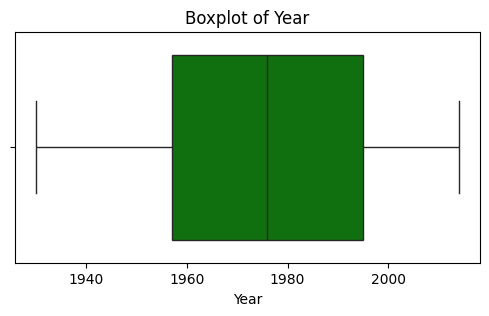

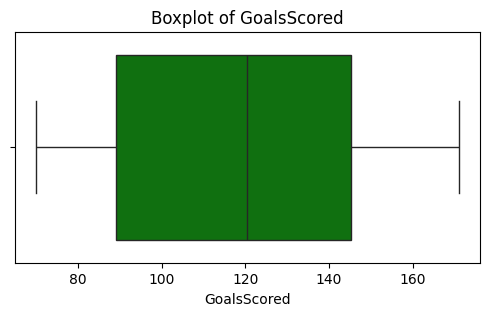

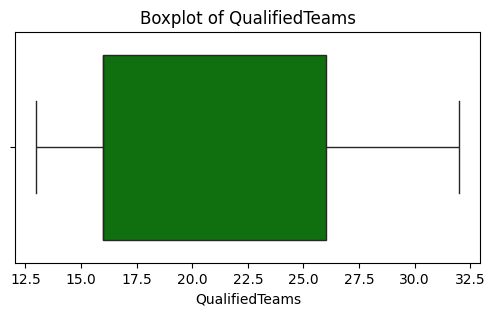

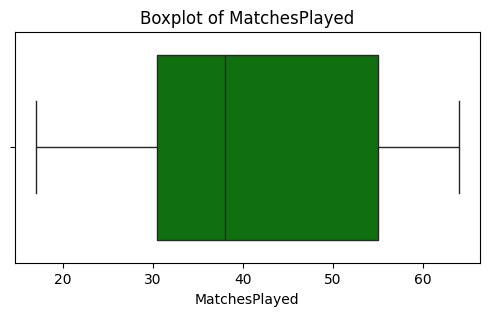

In [62]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns    # checking outliers in numeric columns

for col in num_cols:
    plt.figure(figsize=(6, 3))
    ax = sns.boxplot(x=df[col], color='green')
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

In [63]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

data_ink_ratios = {}

for col in num_cols:

    # We can see each box has: 1 box + 1 median line + 2 whiskers = 4
    # Count outliers
    outliers = df[col][(df[col] < df[col].quantile(0.25) - 1.5*(df[col].quantile(0.75)-df[col].quantile(0.25))) |
                        (df[col] > df[col].quantile(0.75) + 1.5*(df[col].quantile(0.75)-df[col].quantile(0.25)))]
    data_ink = 4 + len(outliers)    # in above case zero outliers

    num_texts = len(ax.texts)  # lengths of title, xlabel, etc
    num_ticks = len(ax.get_xticks())  # number of ticks used
    num_gridlines = len(ax.get_xgridlines()) + len(ax.get_ygridlines()) # number of gridlines used

    total_ink = data_ink + num_texts + num_ticks + num_gridlines

    data_ink_ratio = data_ink / total_ink
    data_ink_ratios[col] = round(data_ink_ratio, 3) # rounding of 3 places after decimal

print("Approximate Data-Ink Ratios for each Boxplot:")
for col, ratio in data_ink_ratios.items():
    print(f"{col}: {ratio}")

Approximate Data-Ink Ratios for each Boxplot:
Year: 0.211
GoalsScored: 0.211
QualifiedTeams: 0.211
MatchesPlayed: 0.211


In [64]:
# 'Host_success' if he is in  winner, runner-up , third or fourth position
df['Host_success'] = df.apply(lambda row: 1 if row['Country'] in [row['Winner'], row['Runners-Up'], row['Third'], row['Fourth']] else 0, axis=1)


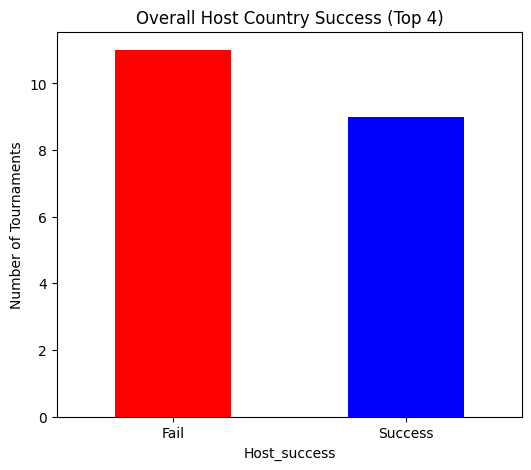

In [65]:
# Count of success VS failure
host_counts = df['Host_success'].value_counts()

plt.figure(figsize=(6,5))
host_counts.plot(kind='bar', color=['red','blue'])
plt.xticks([0,1], ['Fail','Success'], rotation=0)
plt.title('Overall Host Country Success (Top 4)')
plt.ylabel('Number of Tournaments')
plt.show()

In [66]:
# Data-Ink Ratio Calculation
# Data Ink: number of bars + 1 outline each = 2 + 2 = 4
data_ink = len(host_counts) * 2

# non-data ink elements
num_texts = len(ax.texts)               # title, axis labels, tick labels
num_ticks = len(ax.get_xticks()) + len(ax.get_yticks())  # all tick marks
num_gridlines = len(ax.get_xgridlines()) + len(ax.get_ygridlines())

total_ink = data_ink + num_texts + num_ticks + num_gridlines

data_ink_ratio = round(data_ink / total_ink, 3)
print("Approximate Data-Ink Ratio for 'Overall Host Country Success':", data_ink_ratio)

Approximate Data-Ink Ratio for 'Overall Host Country Success': 0.2


Graphical integrity is weaker as the visualization uses excessive ink for gridlines, labels, or colors, reducing efficiency.

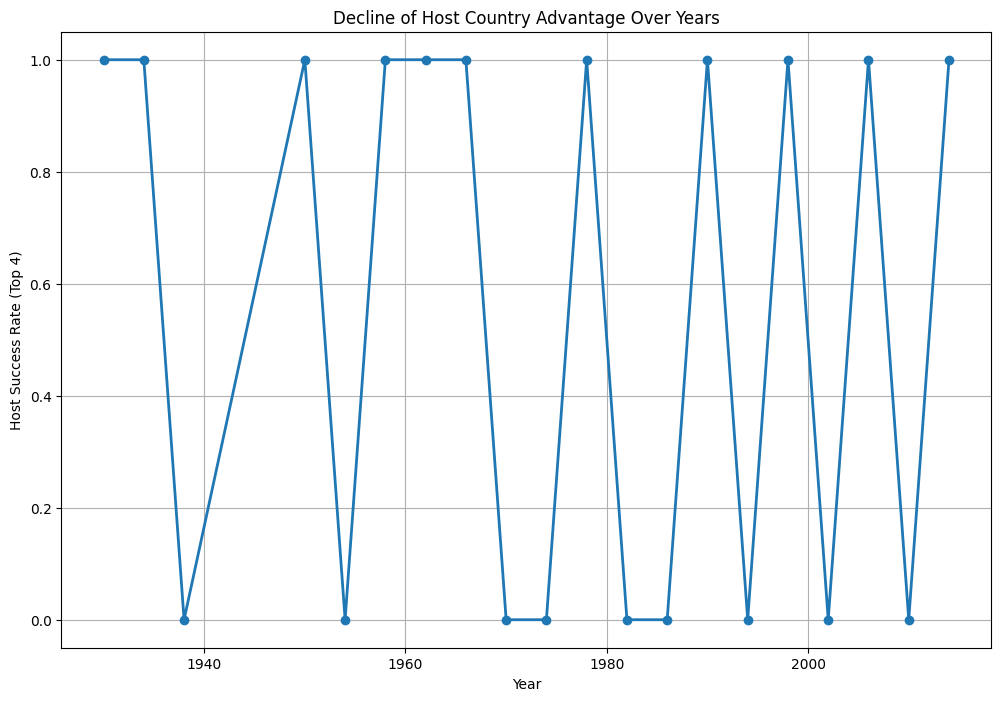

In [67]:
plt.figure(figsize=(12,8))
plt.plot(df['Year'], df['Host_success'], marker='o', linewidth=2)
plt.title('Decline of Host Country Advantage Over Years')
plt.xlabel('Year')
plt.ylabel('Host Success Rate (Top 4)')
plt.grid(True)
plt.show()

In [68]:
# Data-Ink Ratio Calculation

num_points = len(df['Year']) # how many years matched played
data_ink = (num_points - 1) + num_points  # lines between points + markers

# Non-data ink elements
num_texts = len(ax.texts)  # title, axis labels, tick labels
num_ticks = len(ax.get_xticks()) + len(ax.get_yticks())
num_gridlines = len(ax.get_xgridlines()) + len(ax.get_ygridlines())

total_ink = data_ink + num_texts + num_ticks + num_gridlines

data_ink_ratio = round(data_ink / total_ink, 3)
print("Approximate Data-Ink Ratio for 'Decline of Host Country Advantage Over Years':", data_ink_ratio)

Approximate Data-Ink Ratio for 'Decline of Host Country Advantage Over Years': 0.709


Graphical integrity is maintained, visualization shows data clearly, but some ink is spent on unnecessary gridlines or labels.

In [69]:
df['Decade'] = (df['Year'] // 10) * 10
host_decade = df.groupby('Decade')['Host_success'].mean().reset_index()

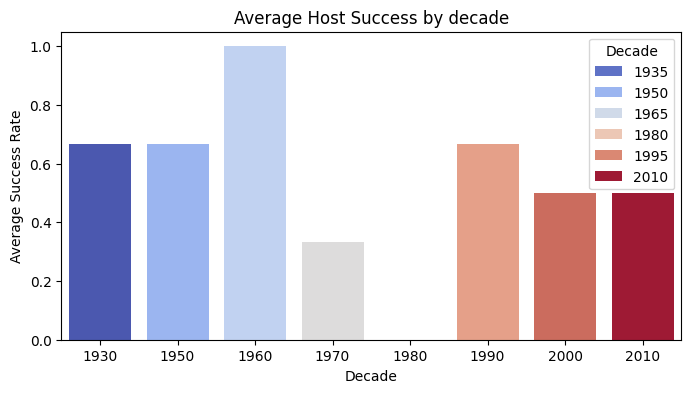

In [70]:
plt.figure(figsize=(8,4))
sns.barplot(x='Decade', y='Host_success', data=df, hue = 'Decade', palette='coolwarm', errorbar=None)
plt.title('Average Host Success by decade')
plt.ylabel('Average Success Rate')
plt.show()

In [71]:
# Data-Ink Ratio Calculation
num_bars = len(df['Decade'].unique())
data_ink = num_bars * 2  # bar + outline

# Non-data ink elements
num_texts = len(ax.texts)
num_ticks = len(ax.get_xticks()) + len(ax.get_yticks())
num_gridlines = len(ax.get_xgridlines()) + len(ax.get_ygridlines())
has_legend = 1

total_ink = data_ink + num_texts + num_ticks + num_gridlines + has_legend

data_ink_ratio = round(data_ink / total_ink, 3)
print("Approximate Data-Ink Ratio for 'Average Host Success by Decade':", data_ink_ratio)

Approximate Data-Ink Ratio for 'Average Host Success by Decade': 0.485


Graphical integrity is maintained, visualization shows data clearly, but some ink is spent on unnecessary gridlines or labels.

In [72]:
df['Attendance'] = df['Attendance'].str.replace('.', '', regex=False)

In [73]:
def host_score(row):
    if row['Winner'] == row['Country']:
        return 4
    elif row['Runners-Up'] == row['Country']:
        return 3
    elif row['Third'] == row['Country']:
        return 2
    elif row['Fourth'] == row['Country']:
        return 1
    else:
        return 0

df['Host_Score'] = df.apply(host_score, axis=1)

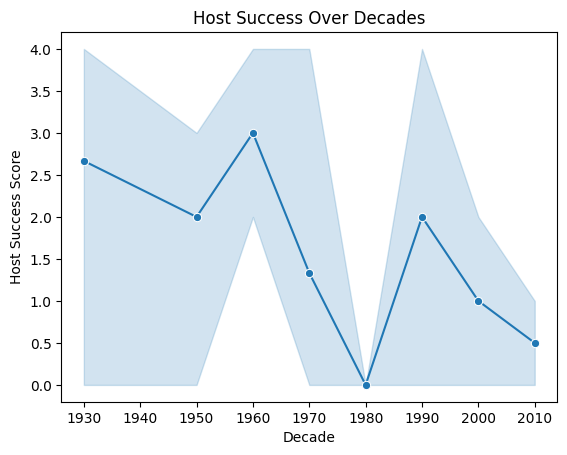

In [74]:
# Line plot showing Host success score over decade
sns.lineplot(data=df, x='Decade', y='Host_Score', marker='o')
plt.title('Host Success Over Decades')
plt.ylabel('Host Success Score')
plt.show()

In [75]:
# Data-Ink Ratio Calculation
# line segments + markers
num_points = len(df['Decade'].unique())
data_ink = (num_points - 1) + num_points  # (lines + markers)

# Non-data ink elements titles, ticks, gridlines, labels
num_texts = len(ax.texts)
num_ticks = len(ax.get_xticks()) + len(ax.get_yticks())
num_gridlines = len(ax.get_xgridlines()) + len(ax.get_ygridlines())

total_ink = data_ink + num_texts + num_ticks + num_gridlines

data_ink_ratio = round(data_ink / total_ink, 3)
print("Approximate Data-Ink Ratio for 'Host Nation Success Over Decades':", data_ink_ratio)

Approximate Data-Ink Ratio for 'Host Nation Success Over Decades': 0.484


Graphical integrity is maintained, visualization shows data clearly, but some ink is spent on unnecessary gridlines or labels.

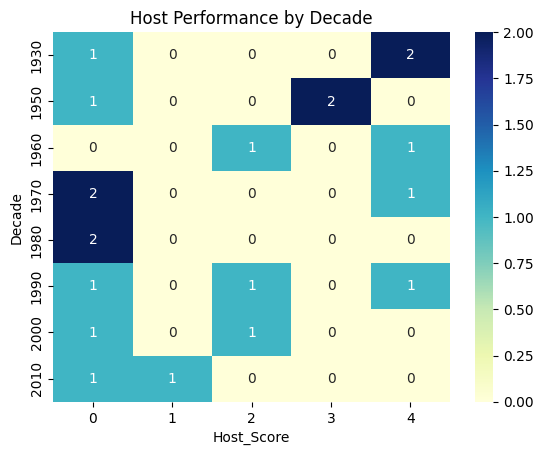

In [76]:
# Count of hosts reaching each stage per decade
host_summary = pd.crosstab(df['Decade'], df['Host_Score'])
sns.heatmap(host_summary, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Host Performance by Decade')
plt.show()

In [77]:
# Data-Ink Ratio Calculation
#  each cell (represents a value) + annotation number in it
num_cells = host_summary.shape[0] * host_summary.shape[1]
data_ink = num_cells * 2  # cell color + number text

# Non-data ink
# title, labels, ticks, gridlines, colorbar
num_texts = len(ax.texts)           # annotations + title
num_ticks = len(ax.get_xticks()) + len(ax.get_yticks())
num_gridlines = len(ax.get_xgridlines()) + len(ax.get_ygridlines())
has_colorbar = 1

total_ink = data_ink + num_texts + num_ticks + num_gridlines + has_colorbar

data_ink_ratio = round(data_ink / total_ink, 3)
print("Approximate Data-Ink Ratio for 'Host Performance by Decade (Heatmap)':", data_ink_ratio)

Approximate Data-Ink Ratio for 'Host Performance by Decade (Heatmap)': 0.825


Graphical integrity is strong, the distribution and key features are clearly conveyed without distraction.

Early decades (1930–1980) show stronger host advantages, with multiple wins and runner-ups.
From 1990 onwards, the advantage of hosting seems to decrease; fewer hosts reach the Top 4 or win.

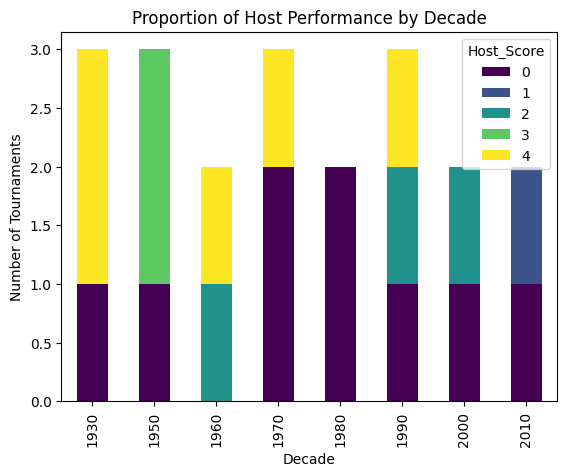

In [78]:
host_summary = pd.crosstab(df['Decade'], df['Host_Score'])
host_summary.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Proportion of Host Performance by Decade')
plt.ylabel('Number of Tournaments')
plt.show()

In [79]:
# Data-Ink Ratio Calculation
# Each stacked sectio one per Host_Score per Decade
num_bars = host_summary.shape[0]     # number of decades
num_sections = num_bars * host_summary.shape[1]
data_ink = num_sections * 2  # section fill + outline

# Non-data ink
# titles, ticks, gridlines, labels, legend
num_texts = len(ax.texts)
num_ticks = len(ax.get_xticks()) + len(ax.get_yticks())
num_gridlines = len(ax.get_xgridlines()) + len(ax.get_ygridlines())
has_legend = 1

total_ink = data_ink + num_texts + num_ticks + num_gridlines + has_legend

data_ink_ratio = round(data_ink / total_ink, 3)
print("Approximate Data-Ink Ratio for 'Proportion of Host Performance by Decade (Stacked Bar Chart)':", data_ink_ratio)

Approximate Data-Ink Ratio for 'Proportion of Host Performance by Decade (Stacked Bar Chart)': 0.825


Graphical integrity is strong, the distribution and key features are clearly conveyed without distraction.

In the total period of 80 years in first 40 years winner yellow bar can be seen bigger and more but next 40 years No winning bar dominates

In [80]:
df3 = pd.read_excel("football_world_cups_results.xlsx", sheet_name="World Cup - Tableau format")

In [81]:
df3.head()

,Year,Game #,Date,Time,Round,Stadium,City,Country,Team,Team G,Opponent,Opponent G,Observation
0,1930,1,1930-07-13,15:00,Group 1,Pocitos,Montevideo,Uruguay,France,4,Mexico,1,
1,1930,1,1930-07-13,15:00,Group 1,Pocitos,Montevideo,Uruguay,Mexico,1,France,4,
2,1930,2,1930-07-13,15:00,Group 4,Parque Central,Montevideo,Uruguay,USA,3,Belgium,0,
3,1930,2,1930-07-13,15:00,Group 4,Parque Central,Montevideo,Uruguay,Belgium,0,USA,3,
4,1930,3,1930-07-14,12:45,Group 2,Parque Central,Montevideo,Uruguay,Yugoslavia,2,Brazil,1,


In [82]:
df3.tail()

,Year,Game #,Date,Time,Round,Stadium,City,Country,Team,Team G,Opponent,Opponent G,Observation
1699,2014,850,2014-07-09,17:00,Semi-finals,Arena de Sao Paulo,Sao Paulo,Brazil,Argentina,0,Netherlands,0,Argentina win on penalties (2 - 4)
1700,2014,851,2014-07-12,17:00,Play-off for third place,Estadio Nacional,Brasilia,Brazil,Brazil,0,Netherlands,3,
1701,2014,851,2014-07-12,17:00,Play-off for third place,Estadio Nacional,Brasilia,Brazil,Netherlands,3,Brazil,0,
1702,2014,852,2014-07-13,16:00,Final,Estadio do Maracana,Rio De Janeiro,Brazil,Germany,1,Argentina,0,Germany win after extra time
1703,2014,852,2014-07-13,16:00,Final,Estadio do Maracana,Rio De Janeiro,Brazil,Argentina,0,Germany,1,Germany win after extra time


In [83]:
df3.shape

(1704, 13)

In [84]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Year         1704 non-null   int64         
 1   Game #       1704 non-null   int64         
 2   Date         1704 non-null   datetime64[ns]
 3   Time         1704 non-null   object        
 4   Round        1704 non-null   object        
 5   Stadium      1704 non-null   object        
 6   City         1704 non-null   object        
 7   Country      1704 non-null   object        
 8   Team         1704 non-null   object        
 9   Team G       1704 non-null   int64         
 10  Opponent     1704 non-null   object        
 11  Opponent G   1704 non-null   int64         
 12  Observation  1704 non-null   object        
dtypes: datetime64[ns](1), int64(4), object(8)
memory usage: 173.2+ KB


In [85]:
df.describe()

,Year,GoalsScored,QualifiedTeams,MatchesPlayed,Host_success,Decade,Host_Score
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.0000
mean,1974.800000,118.950000,21.250000,41.800000,0.550000,1971.000000,1.6500
std,25.582889,32.972836,7.268352,17.218717,0.510418,25.731406,1.7252
min,1930.000000,70.000000,13.000000,17.000000,0.000000,1930.000000,0.0000
25%,1957.000000,89.000000,16.000000,30.500000,0.000000,1950.000000,0.0000
50%,1976.000000,120.500000,16.000000,38.000000,1.000000,1970.000000,1.5000
75%,1995.000000,145.250000,26.000000,55.000000,1.000000,1990.000000,3.2500
max,2014.000000,171.000000,32.000000,64.000000,1.000000,2010.000000,4.0000


In [86]:
df3.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
1699,False
1700,False
1701,False
1702,False


In [87]:
df3.columns

Index(['Year', 'Game #', 'Date', 'Time', 'Round', 'Stadium', 'City', 'Country',
       'Team', 'Team G', 'Opponent', 'Opponent G', 'Observation'],
      dtype='object')

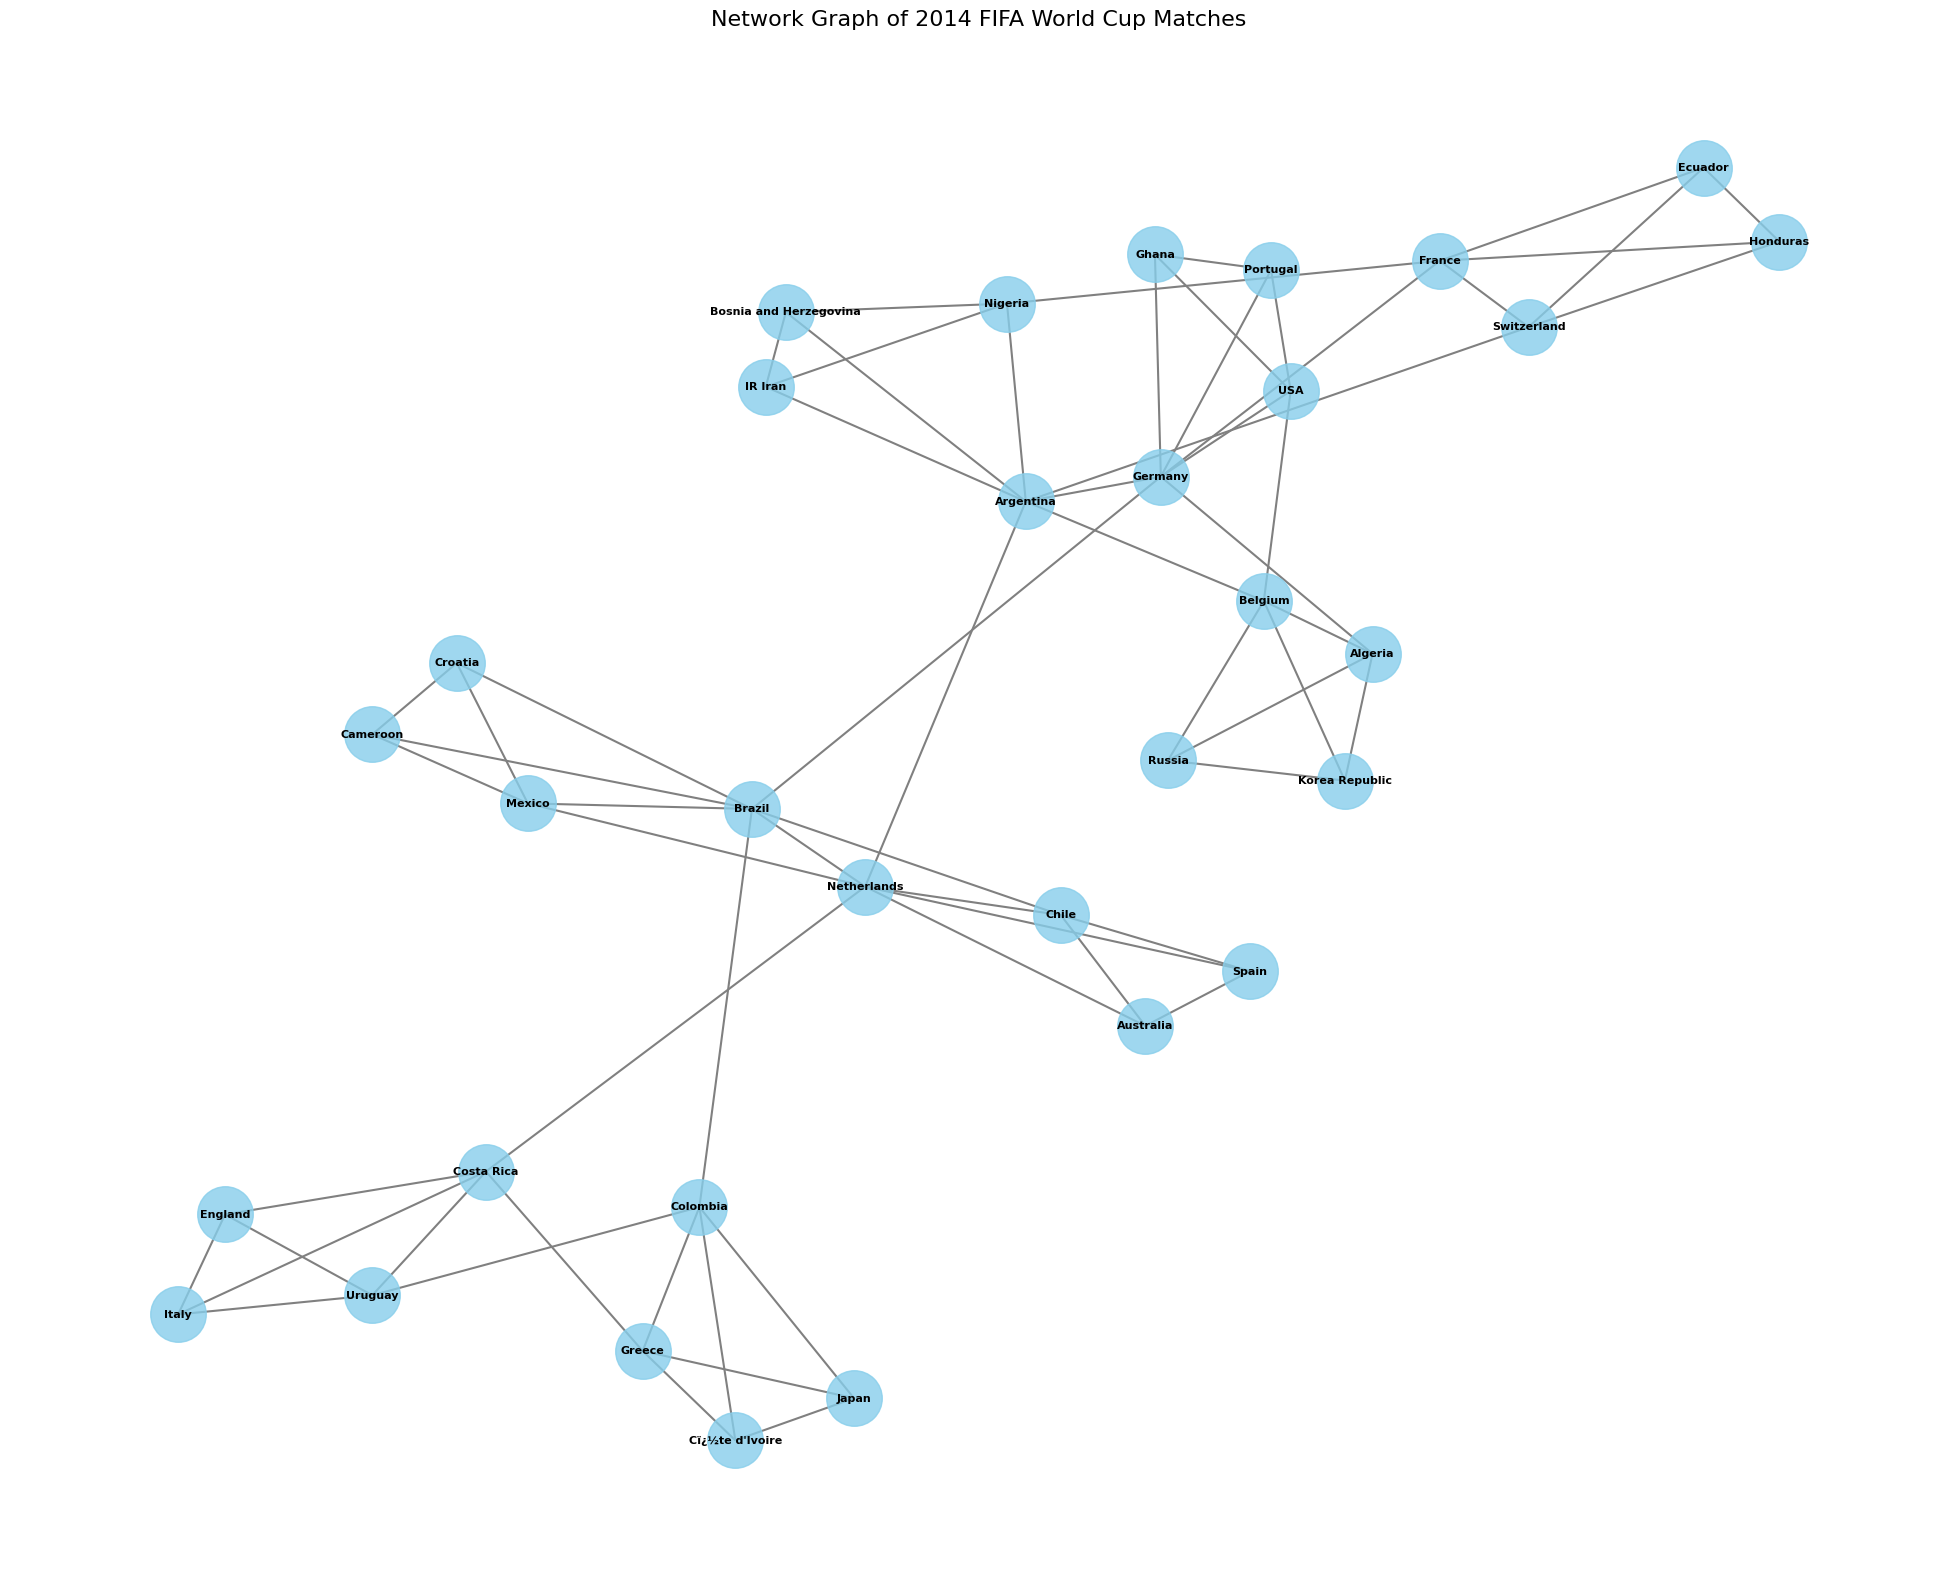

In [88]:

df3_2014 = df3[df3['Year'] == 2014]

G = nx.Graph()

for i, row in df3_2014.iterrows():
    team = row['Team']
    opponent = row['Opponent']
    G.add_edge(team, opponent)

plt.figure(figsize=(25, 20))
pos = nx.spring_layout(G, k=0.35, iterations=50, seed=42)

nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=1600, alpha=0.8)
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1.5)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

plt.title("Network Graph of 2014 FIFA World Cup Matches", fontsize=16)
plt.axis('off')
plt.show()